# Compare ZIG and Poisson KDE state-space classification on deconvolved calcium

This notebook compares two classifier paths on the same simulated calcium pipeline:

1. **ZIG classifier**: `CalciumClassifier` with `deconv_calcium_likelihood`, fit and predicted on the **continuous OASIS output**.
2. **Poisson KDE classifier**: `SortedSpikesClassifier` with `spiking_likelihood_kde`, fit and predicted on **binarized OASIS spikes**.

Both models use the same 3-state state-space structure:

1. **Local**: smooth position evolution (`RandomWalk`)
2. **Stationary**: position stays in one bin (`Identity`)
3. **Jump**: non-local transitions (`Uniform`)


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from replay_trajectory_classification import (
    CalciumClassifier,
    DiagonalDiscrete,
    Environment,
    Identity,
    RandomWalk,
    SortedSpikesClassifier,
    Uniform,
)
from replay_trajectory_classification.calcium_sorted_spikes_decoding import (
    deconvolve_and_binarize,
    deconvolve_continuous,
)
from replay_trajectory_classification.continuous_state_transitions import (
    estimate_movement_var,
)
from replay_trajectory_classification.simulate_calcium import (
    make_continuous_replay,
    make_fragmented_replay,
    make_hover_replay,
    make_simulated_run_data,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_context("talk", font_scale=0.8)
np.random.seed(0)


Cupy is not installed or GPU is not detected. Ignore this message if not using GPU
I0000 00:00:1778655988.874693 1026289 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778655988.902235 1026289 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Instructions for updating:
non-resource variables are not supported in the long term


I0000 00:00:1778655989.473842 1026289 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/likelihoods/multiunit_likelihood.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:13: UserWarning: Could not find cvxpy. Don't worry, you can still use OASIS, just not the slower interior point methods we compared to in the papers.
  warn("Could not find cvxpy. Don't worry, you can still use OASIS, " +


In [2]:
TRACK_HEIGHT = 200.0
N_NEURONS = 20
PLACE_FIELD_MEANS = np.linspace(0.0, TRACK_HEIGHT, N_NEURONS)
SAMPLING_FREQUENCY = 30
INTERNAL_SAMPLING_FREQUENCY = 1000
RUNNING_SPEED = 15.0
SIGMA = 1.0
N_RUNS = 2
STATE_NAMES = ["Local", "Stationary", "Jump"]
PLACE_BIN_SIZE = 1.0

CONTINUOUS_REPLAY_SPEEDUP = 1.0
CONTINUOUS_N_FRAMES = 200
HOVER_N_FRAMES = 90
FRAGMENTED_N_FRAMES = 45

ZIG_GEN_NODES = 64
ZIG_LEARNING_RATE = 1e-3
ZIG_N_EPOCHS = 2000
ZIG_BATCH_SIZE = 512


def make_run_dataset(seed):
    time, position, sampling_frequency, calcium_traces, true_spikes, _ = make_simulated_run_data(
        sampling_frequency=SAMPLING_FREQUENCY,
        internal_sampling_frequency=INTERNAL_SAMPLING_FREQUENCY,
        track_height=TRACK_HEIGHT,
        running_speed=RUNNING_SPEED,
        n_runs=N_RUNS,
        place_field_means=PLACE_FIELD_MEANS,
        sigma=SIGMA,
        rng=np.random.default_rng(seed),
    )
    continuous_deconv = deconvolve_continuous(calcium_traces)
    inferred_spikes = deconvolve_and_binarize(calcium_traces)
    return {
        "time": time,
        "position": position,
        "sampling_frequency": sampling_frequency,
        "calcium_traces": calcium_traces,
        "true_spikes": true_spikes,
        "continuous_deconv": continuous_deconv,
        "inferred_spikes": inferred_spikes,
    }


def make_transition_types(movement_var):
    return [
        [RandomWalk(movement_var=movement_var), Identity(), Uniform()],
        [RandomWalk(movement_var=movement_var), Identity(), Uniform()],
        [Uniform(), Uniform(), Uniform()],
    ]


def make_kde_classifier(movement_var):
    return SortedSpikesClassifier(
        environments=[Environment(environment_name="", place_bin_size=PLACE_BIN_SIZE)],
        continuous_transition_types=make_transition_types(movement_var),
        discrete_transition_type=DiagonalDiscrete(),
        sorted_spikes_algorithm="spiking_likelihood_kde",
        sorted_spikes_algorithm_params={
            "position_std": 3.0,
            "use_diffusion": False,
            "block_size": None,
        },
    )


def make_zig_classifier(movement_var):
    return CalciumClassifier(
        environments=[Environment(environment_name="", place_bin_size=PLACE_BIN_SIZE)],
        continuous_transition_types=make_transition_types(movement_var),
        discrete_transition_type=DiagonalDiscrete(),
        calcium_algorithm="deconv_calcium_likelihood",
        calcium_algorithm_params={
            "gen_nodes": ZIG_GEN_NODES,
            "learning_rate": ZIG_LEARNING_RATE,
            "n_epochs": ZIG_N_EPOCHS,
            "batch_size": ZIG_BATCH_SIZE,
        },
    )


def state_probability(results, posterior_name="acausal_posterior"):
    return getattr(results, posterior_name).sum("position")


def plot_state_probability(ax, results, posterior_name, title):
    posterior = state_probability(results, posterior_name)
    for state in posterior.state.values:
        ax.plot(
            posterior.time.values,
            posterior.sel(state=state).values,
            label=str(state),
            linewidth=2,
        )
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel("Probability")
    ax.set_title(title)
    ax.legend(loc="upper right", frameon=False)


def plot_event_diagnostics(ax, time, calcium_traces, true_spikes, title):
    calcium_span = float(np.nanmax(calcium_traces) - np.nanmin(calcium_traces))
    signal_span = max(0.1, calcium_span)
    offset_step = signal_span + 0.25
    offsets = np.arange(calcium_traces.shape[1]) * offset_step
    spike_height = 0.15 * signal_span

    for neuron_ind, offset in enumerate(offsets):
        ax.plot(time, calcium_traces[:, neuron_ind] + offset, color="black", lw=0.8)
        spike_mask = true_spikes[:, neuron_ind] > 0
        if np.any(spike_mask):
            ax.vlines(
                time[spike_mask],
                offset,
                offset + spike_height,
                color="tab:blue",
                lw=1.0,
            )

    ax.set_yticks(offsets)
    ax.set_yticklabels(np.arange(1, calcium_traces.shape[1] + 1))
    ax.set_ylabel("Neuron")
    ax.set_title(title)


## Fit both classifiers on the same run data

The **ZIG** fit uses TensorFlow 1 and can take a few minutes at `n_epochs=2000`. The **Poisson KDE** path is much faster.

Both classifiers are trained on the same simulated run, but each sees the signal type it is meant to model:

- **ZIG**: continuous OASIS output
- **Poisson KDE**: binarized OASIS spikes


/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],


Estimated movement variance: 9.081 cm^2/frame


W0000 00:00:1778655990.275063 1026346 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778655990.322605 1026289 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
I0000 00:00:1778655990.416893 1026289 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(

  0%|          | 0/20 [00:00<?, ?it/s]

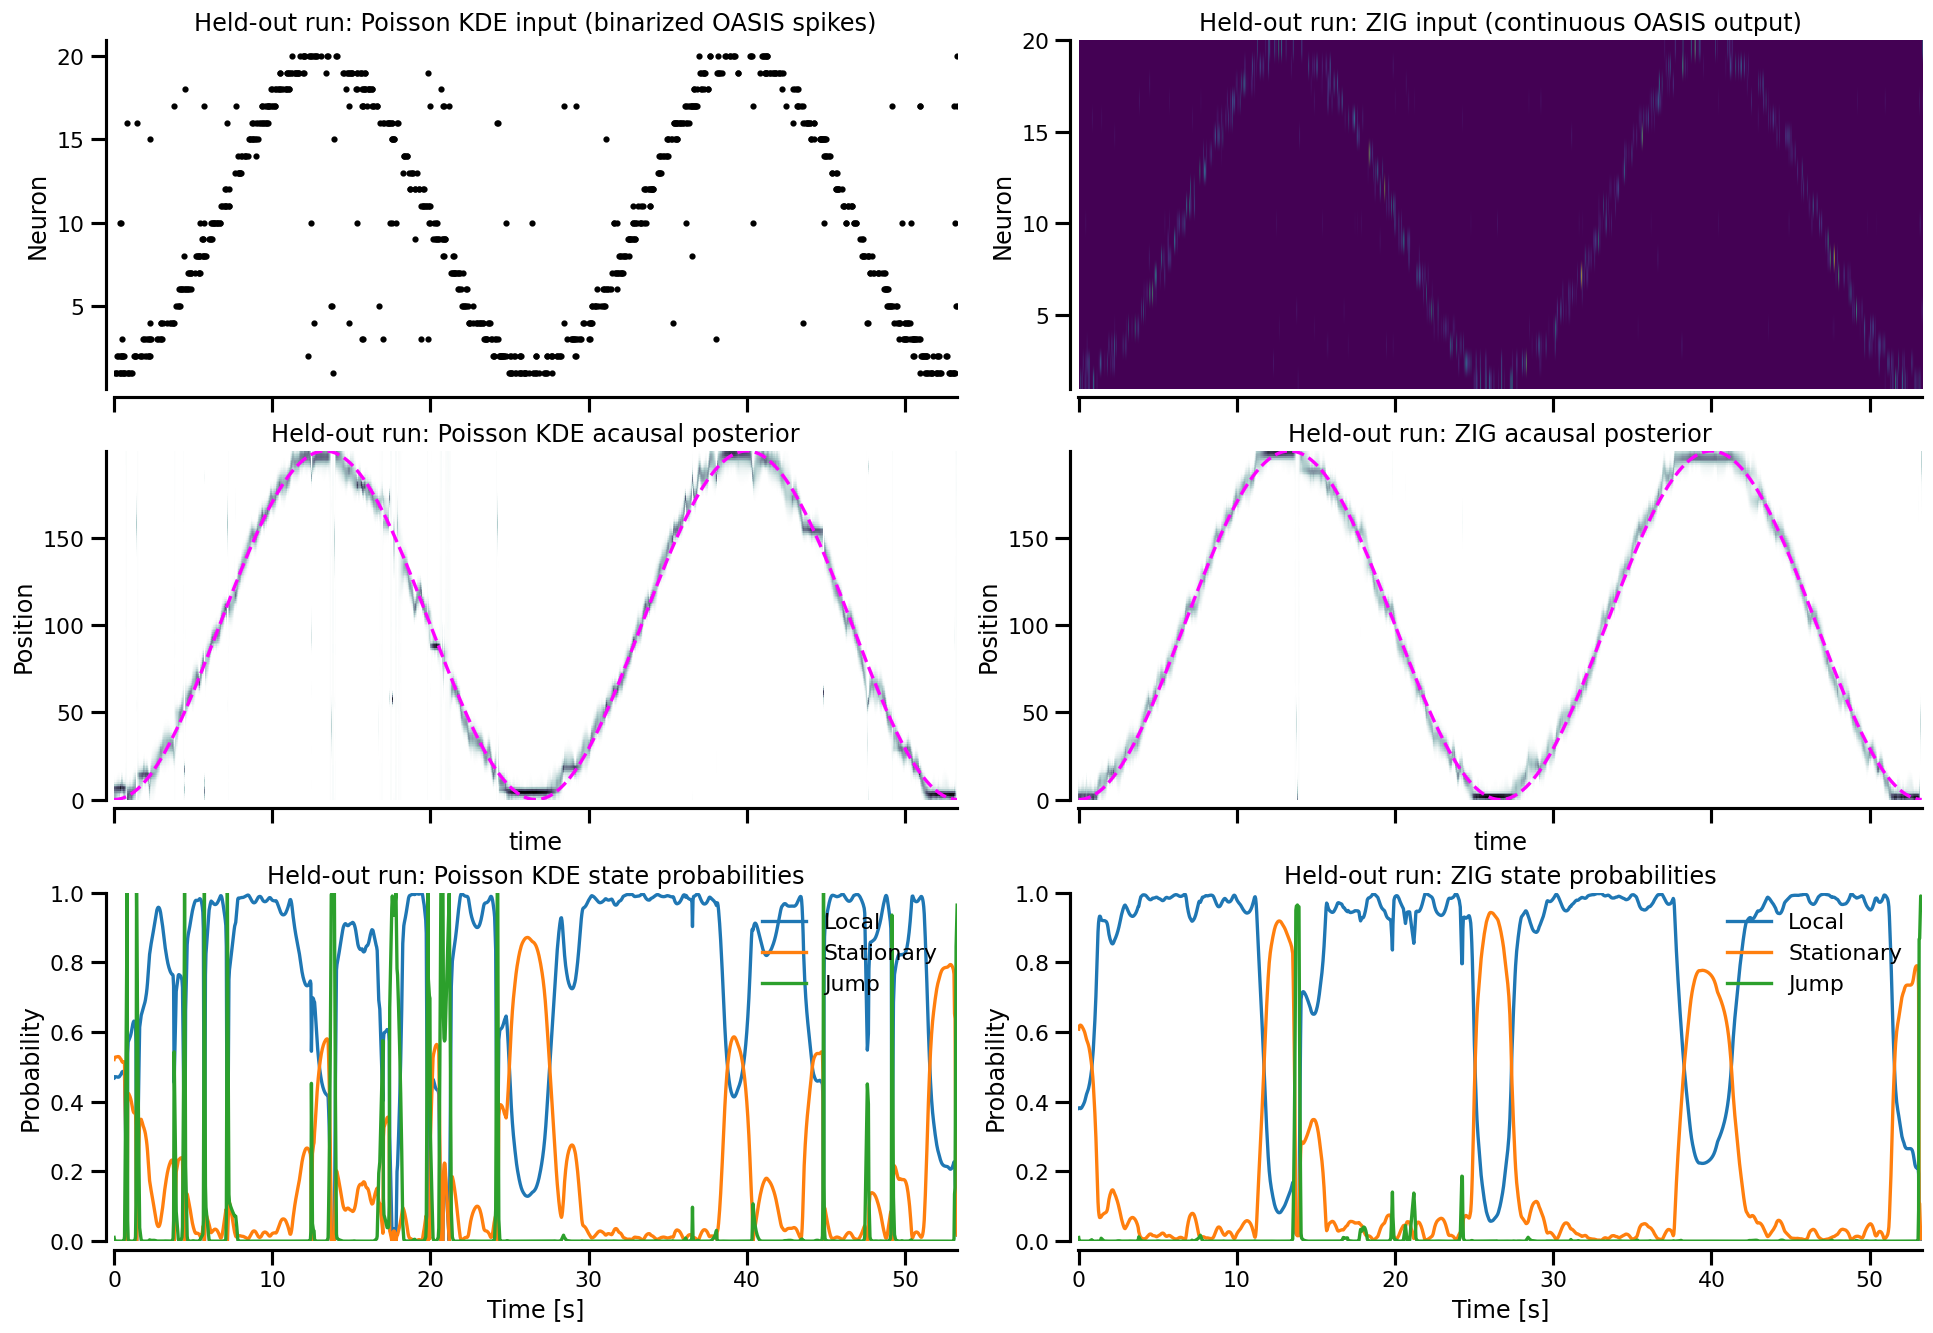

In [3]:
train = make_run_dataset(0)
test = make_run_dataset(1)

movement_var = float(
    estimate_movement_var(train["position"].reshape(-1, 1), SAMPLING_FREQUENCY)
)
print(f"Estimated movement variance: {movement_var:.3f} cm^2/frame")

zig_classifier = make_zig_classifier(movement_var)
kde_classifier = make_kde_classifier(movement_var)

zig_classifier.fit(train["position"], train["continuous_deconv"])
kde_classifier.fit(train["position"], train["inferred_spikes"])

zig_run_results = zig_classifier.predict(
    test["continuous_deconv"],
    time=test["time"],
    state_names=STATE_NAMES,
)
kde_run_results = kde_classifier.predict(
    test["inferred_spikes"],
    time=test["time"],
    state_names=STATE_NAMES,
)

fig, axes = plt.subplots(3, 2, figsize=(16, 11), sharex="col", constrained_layout=True)

spike_time_ind, neuron_ind = np.nonzero(test["inferred_spikes"])
axes[0, 0].scatter(test["time"][spike_time_ind], neuron_ind + 1, s=5, color="black")
axes[0, 0].set_ylabel("Neuron")
axes[0, 0].set_title("Held-out run: Poisson KDE input (binarized OASIS spikes)")

axes[0, 1].imshow(
    test["continuous_deconv"].T,
    aspect="auto",
    origin="lower",
    extent=[test["time"][0], test["time"][-1], 1, test["continuous_deconv"].shape[1]],
    cmap="viridis",
)
axes[0, 1].set_ylabel("Neuron")
axes[0, 1].set_title("Held-out run: ZIG input (continuous OASIS output)")

kde_run_results.acausal_posterior.sum("state").plot(
    x="time", y="position", ax=axes[1, 0], cmap="bone_r", add_colorbar=False
)
axes[1, 0].plot(test["time"], test["position"], color="magenta", linestyle="--", linewidth=2)
axes[1, 0].set_ylabel("Position")
axes[1, 0].set_title("Held-out run: Poisson KDE acausal posterior")

zig_run_results.acausal_posterior.sum("state").plot(
    x="time", y="position", ax=axes[1, 1], cmap="bone_r", add_colorbar=False
)
axes[1, 1].plot(test["time"], test["position"], color="magenta", linestyle="--", linewidth=2)
axes[1, 1].set_ylabel("Position")
axes[1, 1].set_title("Held-out run: ZIG acausal posterior")

plot_state_probability(
    axes[2, 0],
    kde_run_results,
    "acausal_posterior",
    "Held-out run: Poisson KDE state probabilities",
)
plot_state_probability(
    axes[2, 1],
    zig_run_results,
    "acausal_posterior",
    "Held-out run: ZIG state probabilities",
)

for ax in axes[-1, :]:
    ax.set_xlabel("Time [s]")

sns.despine(offset=5)


## Compare event classification

Each event is decoded from the model-specific deconvolved signal, with no access to the ground-truth spikes during prediction.

The left diagnostic column aligns the raw calcium traces with the ground-truth spikes. When the posteriors look fragmented, compare that column against the deconvolved-signal columns: the event-time OASIS output is often much broader than the sparse ground-truth spikes, which pushes both models toward the non-local **Jump** state.

Columns below are:

1. Raw calcium traces + GT spikes
2. ZIG acausal posterior
3. ZIG acausal state probabilities
4. Poisson KDE acausal posterior
5. Poisson KDE acausal state probabilities


/home/ericliu/anaconda3/lib/python3.13/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 200, using nperseg = 200
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],


  0%|          | 0/20 [00:00<?, ?it/s]

/home/ericliu/anaconda3/lib/python3.13/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 90, using nperseg = 90
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],


  0%|          | 0/20 [00:00<?, ?it/s]

/home/ericliu/anaconda3/lib/python3.13/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 45, using nperseg = 45
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],


  0%|          | 0/20 [00:00<?, ?it/s]

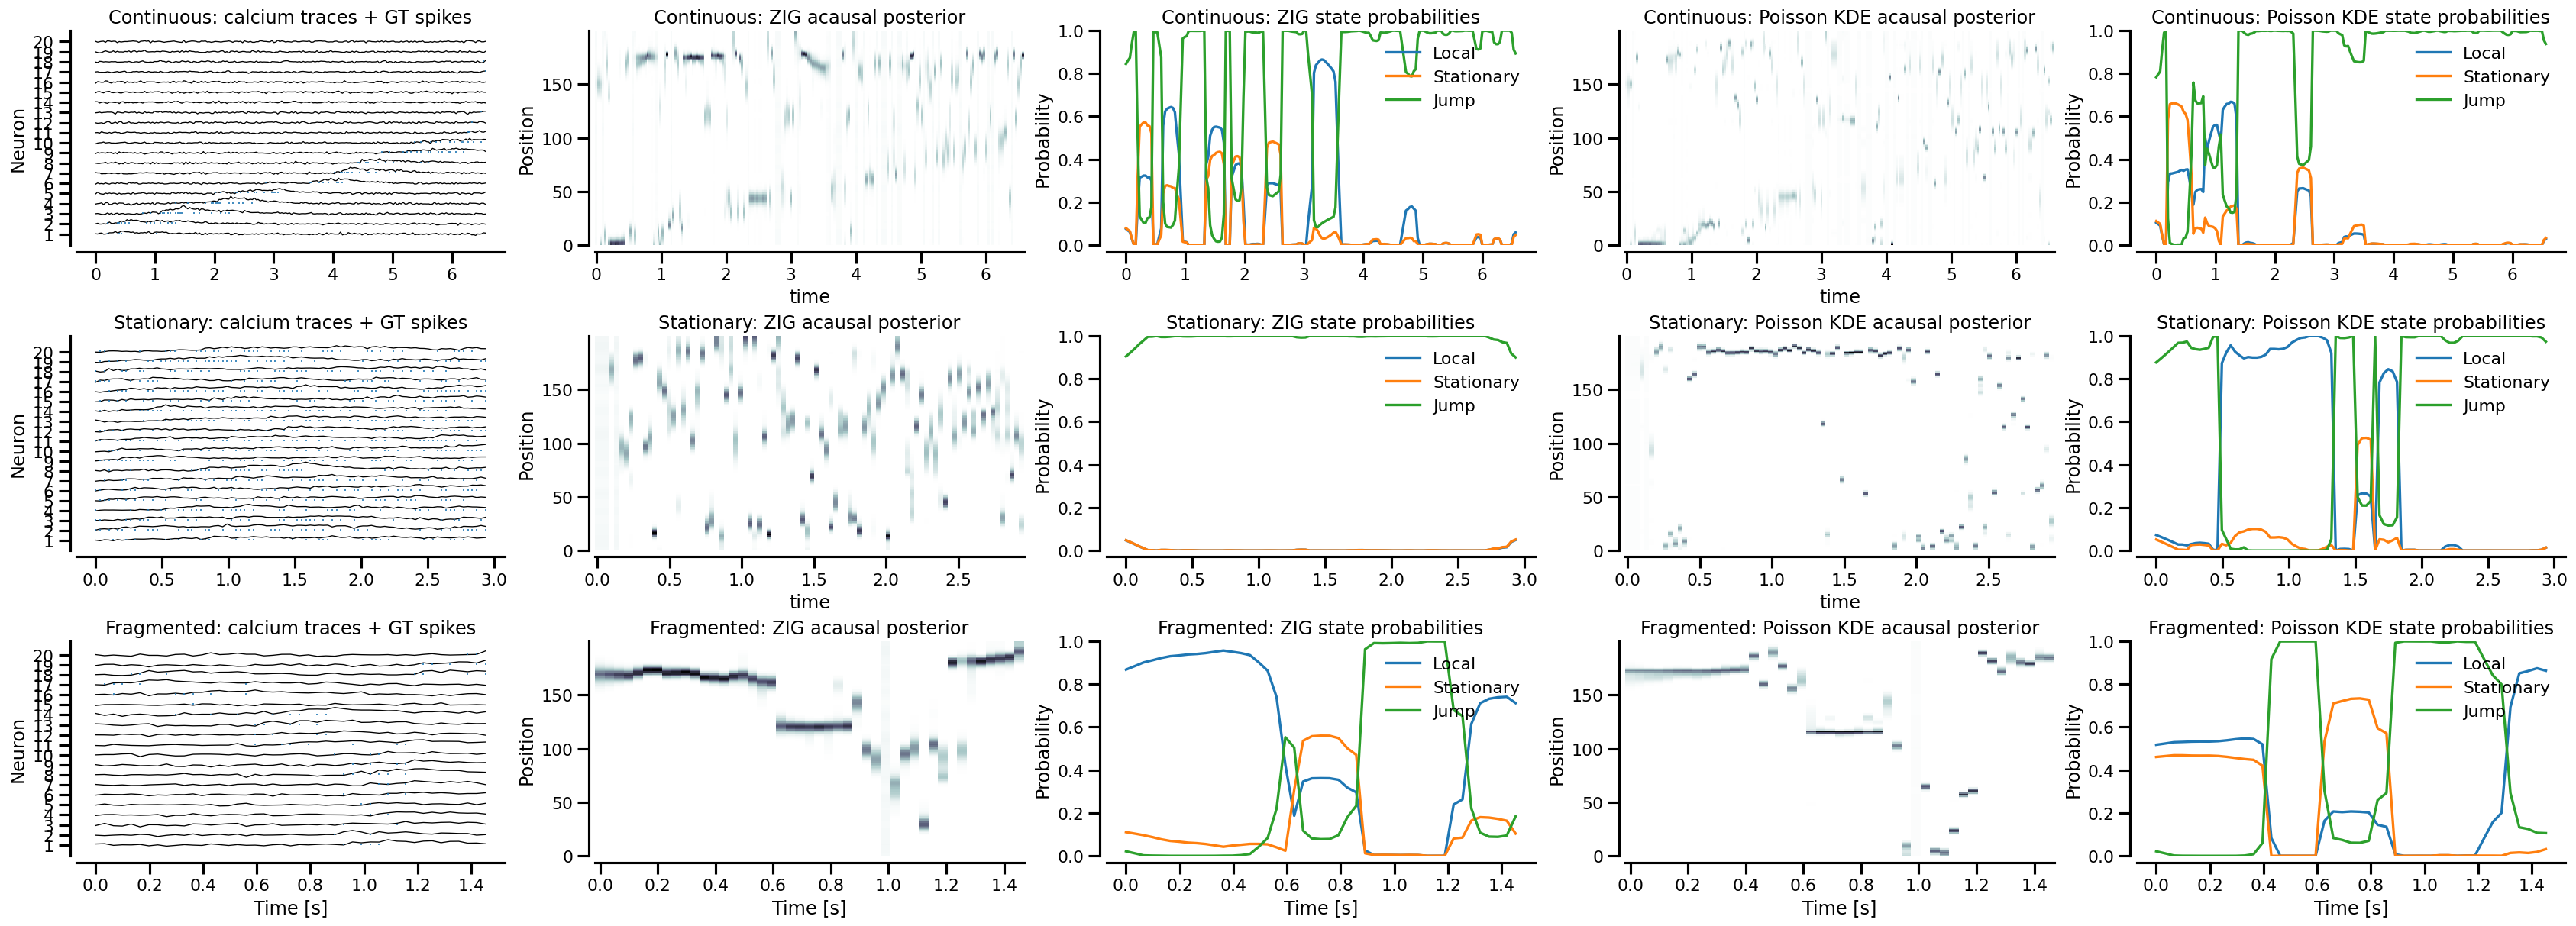

In [4]:
def make_event_dataset(name, event_fn, seed, **event_kwargs):
    time, true_spikes, calcium_traces = event_fn(
        sampling_frequency=SAMPLING_FREQUENCY,
        internal_sampling_frequency=INTERNAL_SAMPLING_FREQUENCY,
        place_field_means=PLACE_FIELD_MEANS,
        sigma=SIGMA,
        rng=np.random.default_rng(seed),
        **event_kwargs,
    )
    continuous_deconv = deconvolve_continuous(calcium_traces)
    inferred_spikes = deconvolve_and_binarize(calcium_traces)
    zig_results = zig_classifier.predict(
        continuous_deconv,
        time=time,
        state_names=STATE_NAMES,
    )
    kde_results = kde_classifier.predict(
        inferred_spikes,
        time=time,
        state_names=STATE_NAMES,
    )
    return {
        "name": name,
        "time": time,
        "true_spikes": true_spikes,
        "calcium_traces": calcium_traces,
        "continuous_deconv": continuous_deconv,
        "inferred_spikes": inferred_spikes,
        "zig_results": zig_results,
        "kde_results": kde_results,
    }


event_datasets = [
    make_event_dataset(
        "Continuous",
        make_continuous_replay,
        2,
        track_height=TRACK_HEIGHT,
        running_speed=RUNNING_SPEED,
        n_frames=CONTINUOUS_N_FRAMES,
        replay_speedup=CONTINUOUS_REPLAY_SPEEDUP,
    ),
    make_event_dataset(
        "Stationary",
        make_hover_replay,
        3,
        n_frames=HOVER_N_FRAMES,
    ),
    make_event_dataset(
        "Fragmented",
        make_fragmented_replay,
        4,
        n_frames=FRAGMENTED_N_FRAMES,
    ),
]

fig, axes = plt.subplots(len(event_datasets), 5, figsize=(28, 10), constrained_layout=True)

for row_ind, dataset in enumerate(event_datasets):
    plot_event_diagnostics(
        axes[row_ind, 0],
        dataset["time"],
        dataset["calcium_traces"],
        dataset["true_spikes"],
        f"{dataset['name']}: calcium traces + GT spikes",
    )
    dataset["zig_results"].acausal_posterior.sum("state").plot(
        x="time", y="position", ax=axes[row_ind, 1], cmap="bone_r", add_colorbar=False
    )
    axes[row_ind, 1].set_title(f"{dataset['name']}: ZIG acausal posterior")
    axes[row_ind, 1].set_ylabel("Position")
    plot_state_probability(
        axes[row_ind, 2],
        dataset["zig_results"],
        "acausal_posterior",
        f"{dataset['name']}: ZIG state probabilities",
    )
    dataset["kde_results"].acausal_posterior.sum("state").plot(
        x="time", y="position", ax=axes[row_ind, 3], cmap="bone_r", add_colorbar=False
    )
    axes[row_ind, 3].set_title(f"{dataset['name']}: Poisson KDE acausal posterior")
    axes[row_ind, 3].set_ylabel("Position")
    plot_state_probability(
        axes[row_ind, 4],
        dataset["kde_results"],
        "acausal_posterior",
        f"{dataset['name']}: Poisson KDE state probabilities",
    )

for ax in axes[-1, :]:
    ax.set_xlabel("Time [s]")

sns.despine(offset=5)
